# Supply Chain Management Group 4

# Linear Regression and KNN Regression By Chinelo Lydia Nweke

## 1.0 Import Libraries

In this section, we import all the libraries needed for the full modelling pipeline. This includes data manipulation tools, visualisation libraries, machine learning algorithms, and evaluation metrics. Importing everything at the start keeps the notebook organised and makes it easy to confirm all dependencies are available before running any analysis.

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     KFold, cross_validate, cross_val_score)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import f_regression, mutual_info_regression

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


## 1.1 Load Data

The final cleaned and feature-engineered dataset is loaded here. This file already contains the merged tube assembly data and the power-transformed target variable `cost_transformed`, so modelling can begin without repeating any of the earlier data preparation steps.

In [86]:
Final_DF = pd.read_csv(
    r"C:\Users\nweke\OneDrive\Desktop\Industrial_Analytics\industrial-analytics-ss2026\Final_DF.csv"
)

print("Dataset shape:", Final_DF.shape)
print("\nColumns:", Final_DF.columns.tolist())
print("\nData types:")
print(Final_DF.dtypes)
print("\nMissing values:")
print(Final_DF.isnull().sum())
Final_DF.head()

Dataset shape: (30213, 49)

Columns: ['Unnamed: 0', 'tube_assembly_id', 'supplier', 'annual_usage', 'min_order_quantity', 'bracket_pricing', 'quantity', 'cost', 'diameter', 'wall', 'length', 'num_bends', 'bend_radius', 'end_a_1x', 'end_a_2x', 'end_x_1x', 'end_x_2x', 'end_a', 'end_x', 'num_boss', 'num_bracket', 'other', 'year', 'year_group', 'month', 'dayofyear', 'dayofweek', 'day', 'end_a_forming', 'end_x_forming', 'component_id_1', 'quantity_1', 'component_id_2', 'quantity_2', 'component_id_3', 'quantity_3', 'component_id_4', 'quantity_4', 'component_id_5', 'quantity_5', 'component_id_6', 'quantity_6', 'component_id_7', 'quantity_7', 'component_id_8', 'quantity_8', 'Total_quantity', 'Total_weight', 'cost_transformed']

Data types:
Unnamed: 0              int64
tube_assembly_id        int64
supplier                int64
annual_usage            int64
min_order_quantity      int64
bracket_pricing         int64
quantity                int64
cost                  float64
diameter          

,Unnamed: 0,tube_assembly_id,supplier,annual_usage,min_order_quantity,bracket_pricing,quantity,cost,diameter,wall,...,quantity_5,component_id_6,quantity_6,component_id_7,quantity_7,component_id_8,quantity_8,Total_quantity,Total_weight,cost_transformed
0,0,2,66,0,1,1,1,21.905933,6.35,0.71,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.018,1.166885
1,1,2,66,0,2,1,2,12.341214,6.35,0.71,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.018,1.133882
2,2,2,66,0,5,1,5,6.601826,6.35,0.71,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.018,1.098963
3,3,2,66,0,10,1,10,4.687770,6.35,0.71,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.018,1.080310
4,4,2,66,0,25,1,25,3.541561,6.35,0.71,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.018,1.065270


**Insight:** The dataset contains 30,213 rows and 49 columns, reflecting the full set of features produced after merging and engineering the tube assembly data. There are no missing values, confirming that all nulls were handled during data preparation. The `cost_transformed` column is the power-transformed version of supplier quote cost, computed as `cost ** (1/20)` to reduce the effect of extreme high-cost outliers during model training. Not all 49 columns will be used for modelling. The feature selection step below narrows this down to the 7 most relevant variables.

## 1.2 Feature Analysis Before Modelling

Before selecting features, I run two statistical tests across all available numeric columns to find out which ones actually matter for predicting cost. F-regression measures the linear association between each feature and the target by computing an F-statistic and p-value. A higher F-score means a stronger linear relationship. Mutual Information captures both linear and non-linear associations, making it a useful complement. Running both tests on all columns lets the data decide which features are worth keeping, rather than making that choice manually without evidence.

In [87]:
# Separate target columns from features
target_cols = ['cost', 'cost_transformed']
all_features = [col for col in Final_DF.select_dtypes(include=[np.number]).columns
                if col not in target_cols]

X_all = Final_DF[all_features]
y_all = Final_DF['cost_transformed']

# F-regression: tests linear association between each feature and target
f_scores, p_values = f_regression(X_all, y_all)

# Mutual Information: captures linear and non-linear associations
mi_scores = mutual_info_regression(X_all, y_all, random_state=42)

feature_scores = pd.DataFrame({
    'Feature':            all_features,
    'F-Score':            f_scores.round(2),
    'P-Value':            p_values.round(6),
    'Mutual Information': mi_scores.round(4)
}).sort_values('F-Score', ascending=False).reset_index(drop=True)

print(f"Total features analysed: {len(all_features)}")
print("\nFeature Importance Summary (sorted by F-Score):")
print(feature_scores.to_string(index=False))

Total features analysed: 45

Feature Importance Summary (sorted by F-Score):
           Feature  F-Score  P-Value  Mutual Information
          diameter  5907.27 0.000000              0.1973
min_order_quantity  5581.51 0.000000              0.6205
          quantity  5469.89 0.000000              0.6117
      Total_weight  3719.45 0.000000              0.3657
              wall  3401.25 0.000000              0.1651
    component_id_1  2398.50 0.000000              0.2857
        quantity_1  2302.67 0.000000              0.1291
    component_id_2  1711.19 0.000000              0.1941
          end_x_2x  1468.51 0.000000              0.0276
    component_id_3  1281.09 0.000000              0.1578
          num_boss  1232.98 0.000000              0.0185
          end_a_2x  1153.60 0.000000              0.0230
            length   939.59 0.000000              0.2032
     end_a_forming   897.62 0.000000              0.0841
        quantity_3   817.98 0.000000              0.0861
          e

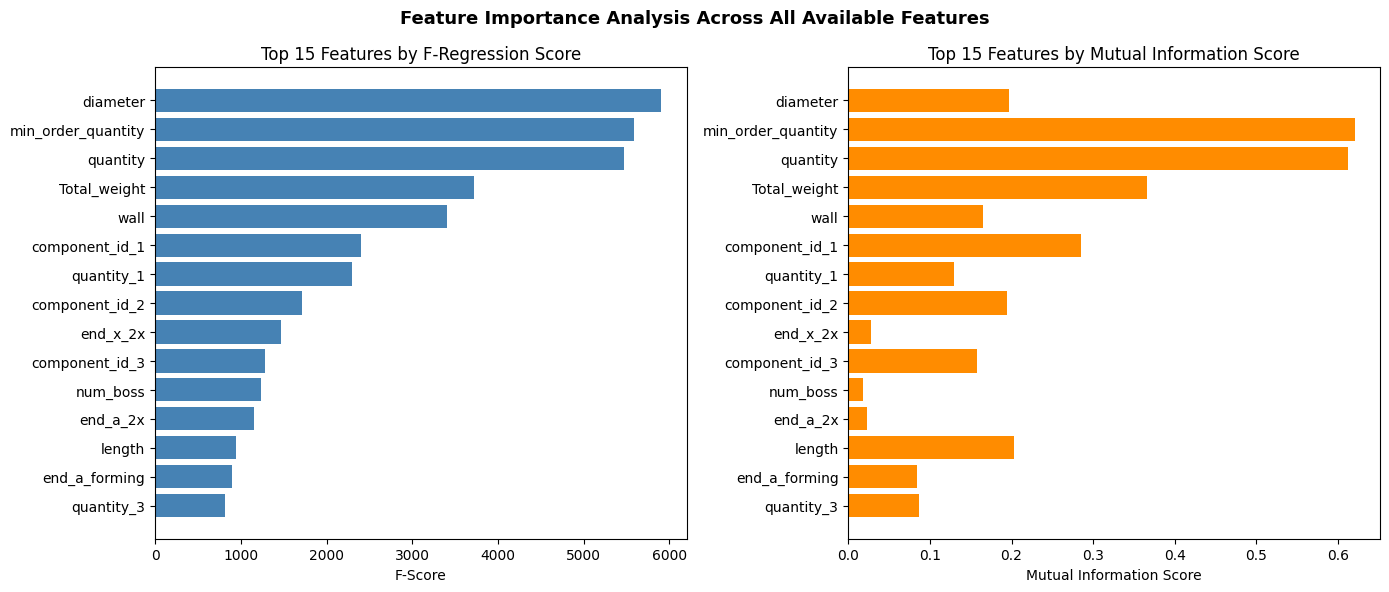

In [88]:
top_n = 15
top_features = feature_scores.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# F-Scores bar chart
axes[0].barh(top_features['Feature'], top_features['F-Score'], color='steelblue')
axes[0].set_xlabel('F-Score')
axes[0].set_title(f'Top {top_n} Features by F-Regression Score')
axes[0].invert_yaxis()

# Mutual Information bar chart
axes[1].barh(top_features['Feature'], top_features['Mutual Information'], color='darkorange')
axes[1].set_xlabel('Mutual Information Score')
axes[1].set_title(f'Top {top_n} Features by Mutual Information Score')
axes[1].invert_yaxis()

plt.suptitle('Feature Importance Analysis Across All Available Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** The F-regression ranks `diameter`, `min_order_quantity`, and `quantity` as the top three features by linear association with the target. Mutual Information scores confirm this finding, with `min_order_quantity` and `quantity` scoring highest, indicating they have strong non-linear relationships with cost as well as linear ones. `Total_weight` and `wall` also rank highly across both methods. Features that scored low on both tests contribute little predictive value and are left out. The seven features selected in the next section are those that appear consistently in the top rankings across both methods.

## 1.3 Feature Selection

Based on the F-regression and Mutual Information analysis above, seven features are selected as model inputs. All seven are statistically significant and collectively represent the physical properties of the tube assembly and the commercial context of the order. The target variable is `cost_transformed`, which is the power-transformed cost computed as `cost ** (1/20)` to reduce the skewness of the original price distribution before modelling.

In [89]:
selected_features = ['diameter', 'min_order_quantity', 'quantity',
                     'Total_weight', 'wall', 'length', 'Total_quantity']

X = Final_DF[selected_features].copy()
y = Final_DF['cost_transformed'].copy()

print("Selected features:", selected_features)
print("\nFeature matrix X shape:", X.shape)
print("Target vector y shape:  ", y.shape)
print("\nDescriptive statistics for X:")
X.describe().round(4)

Selected features: ['diameter', 'min_order_quantity', 'quantity', 'Total_weight', 'wall', 'length', 'Total_quantity']

Feature matrix X shape: (30213, 7)
Target vector y shape:   (30213,)

Descriptive statistics for X:


,diameter,min_order_quantity,quantity,Total_weight,wall,length,Total_quantity
count,30213.000,30213.0000,30213.0000,30213.0000,30213.0000,30213.0000,30213.0000
mean,17.223,38.8845,38.3894,0.1868,1.3848,97.6476,2.9267
std,18.126,70.8120,70.7614,0.6315,0.6386,63.2301,1.1765
min,3.180,1.0000,1.0000,0.0000,0.7100,0.0000,0.0000
25%,9.520,2.0000,2.0000,0.0280,0.8900,48.0000,2.0000
50%,12.700,10.0000,10.0000,0.0650,1.2400,86.0000,3.0000
75%,19.050,50.0000,40.0000,0.1430,1.6500,133.0000,4.0000
max,203.200,2500.0000,2500.0000,27.4760,7.9000,1333.0000,13.0000


**Insight:** The feature matrix X contains 30,213 observations across 7 features, and the target vector y holds the corresponding power-transformed cost values. The descriptive statistics confirm that features vary significantly in scale. For example, `quantity` and `min_order_quantity` reach values in the thousands while `wall` is measured in small decimal fractions. This difference in scale is the reason `StandardScaler` is applied inside every model pipeline, so that no single feature dominates the model simply because of its unit of measurement.

## 2. Linear Regression

This section applies Linear Regression to predict supplier quote cost. The pipeline follows six structured phases: data splitting, baseline modelling, hyperparameter tuning, validation, final test evaluation, and explainability. Two baseline variants are compared first so the choice of target scale is backed by evidence, not assumption.

### Phase 1: 3-Way Data Split

Before any model is trained, the data is divided into three non-overlapping sets. The training set (60%) is used to fit the model. The validation set (20%) is used to compare tuning choices. The test set (20%) is sealed immediately and is not used for any decision until Phase 5, ensuring the final reported performance reflects true generalisation.

In [90]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42
)

print(f"Training set   : {X_train.shape[0]:>5} rows  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Validation set : {X_val.shape[0]:>5} rows  ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test set       : {X_test.shape[0]:>5} rows  ({X_test.shape[0]/len(X)*100:.0f}%)  <- sealed until Phase 5")

Training set   : 18127 rows  (60%)
Validation set :  6043 rows  (20%)
Test set       :  6043 rows  (20%)  <- sealed until Phase 5


**Insight:** With 30,213 samples the training set contains approximately 18,127 rows, the validation set 6,043 rows, and the test set 6,043 rows. Each partition is large enough for reliable metric estimation. Setting `random_state=42` ensures the split is reproducible.

### Helper Function: Evaluation on the Original Dollar Scale

All models are trained on the power-transformed target (`cost ** (1/20)`). To report metrics that are meaningful in business terms, predictions must be converted back to the original dollar scale before computing MAE, RMSE, and R2. The `evaluate` function below handles this back-transformation for any pipeline passed to it.

In [91]:
def evaluate(pipeline, X, y_trans_true, label=""):
    y_pred_trans = pipeline.predict(X)
    y_true_orig  = (y_trans_true ** 20).reset_index(drop=True)
    y_pred_orig  = np.clip(y_pred_trans, 0, None) ** 20
    mae  = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    r2   = r2_score(y_true_orig, y_pred_orig)
    if label:
        print(f"  {label:48s}  MAE=${mae:8.4f}  RMSE=${rmse:8.4f}  R2={r2:.4f}")
    return {"MAE": mae, "RMSE": rmse, "R2": r2,
            "y_true": y_true_orig, "y_pred": y_pred_orig}

### Phase 2: Baseline Models

Two baseline Linear Regression models are trained and compared:

- **Model A** is trained on the raw, untransformed cost values.
- **Model B** is trained on the power-transformed cost (`cost_transformed = cost ** (1/20)`).

Each model is evaluated on the validation set and with 5-fold cross-validation on the training set. Cross-validation averages performance across five different subsets of the training data, giving a more reliable stability measure than any single validation split. The model with the higher and more consistent CV R2 is selected for hyperparameter tuning.

#### Model A: Linear Regression on Raw Cost

Model A uses a `StandardScaler + LinearRegression` pipeline trained directly on the untransformed cost values. This is the simplest possible baseline with no transformation and no regularisation.

In [92]:
y_train_raw = y_train ** 20
y_val_raw   = y_val   ** 20

model_A = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])
model_A.fit(X_train, y_train_raw)

y_pred_A = model_A.predict(X_val)

mae_A  = mean_absolute_error(y_val_raw, y_pred_A)
rmse_A = np.sqrt(mean_squared_error(y_val_raw, y_pred_A))
r2_A   = r2_score(y_val_raw, y_pred_A)

print("=== Model A: Linear Regression (Raw Cost) ===")
print(f"Validation MAE  : ${mae_A:.4f}")
print(f"Validation RMSE : ${rmse_A:.4f}")
print(f"Validation R2   : {r2_A:.4f}")

=== Model A: Linear Regression (Raw Cost) ===
Validation MAE  : $10.0363
Validation RMSE : $27.7100
Validation R2   : 0.2223


#### Model A: 5-Fold Cross-Validation

The training set is divided into 5 folds. The model trains on 4 folds and is evaluated on the remaining one, rotating 5 times. The spread of R2 scores across folds shows how stable Model A is when the training data changes.

In [93]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_A = cross_validate(
    model_A, X_train, y_train_raw,
    cv=kf,
    scoring={'r2': 'r2', 'mae': 'neg_mean_absolute_error',
             'rmse': 'neg_root_mean_squared_error'}
)

cv_r2_A   =  cv_A['test_r2'].mean()
cv_mae_A  = -cv_A['test_mae'].mean()
cv_rmse_A = -cv_A['test_rmse'].mean()

print("=== Model A: 5-Fold Cross-Validation (Raw Cost) ===")
print(f"CV MAE  : ${cv_mae_A:.4f}")
print(f"CV RMSE : ${cv_rmse_A:.4f}")
print(f"CV R2   : {cv_r2_A:.4f}")
print(f"All CV R2 scores: {cv_A['test_r2'].round(3)}")

=== Model A: 5-Fold Cross-Validation (Raw Cost) ===
CV MAE  : $9.8345
CV RMSE : $24.5028
CV R2   : 0.2615
All CV R2 scores: [0.242 0.268 0.244 0.289 0.265]


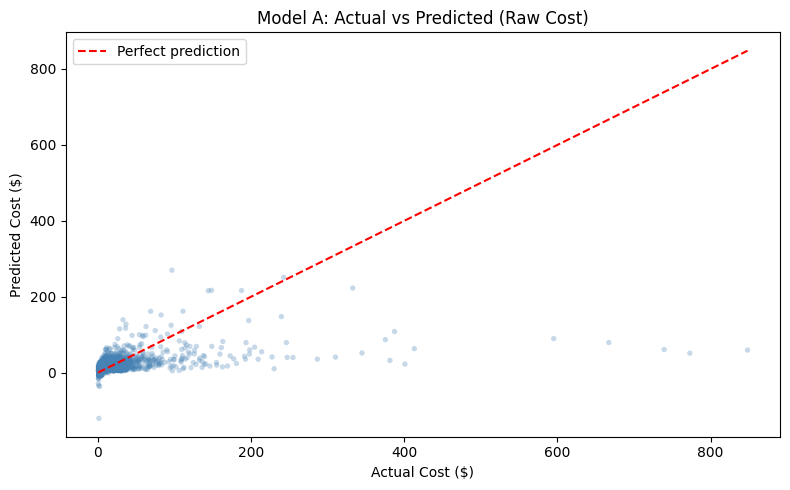

In [94]:
plt.figure(figsize=(8, 5))
plt.scatter(y_val_raw, y_pred_A, alpha=0.3, color='steelblue', edgecolors='none', s=15)
plt.plot([y_val_raw.min(), y_val_raw.max()],
         [y_val_raw.min(), y_val_raw.max()],
         'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Cost ($)')
plt.ylabel('Predicted Cost ($)')
plt.title('Model A: Actual vs Predicted (Raw Cost)')
plt.legend()
plt.tight_layout()
plt.show()

**Insight:** Model A on raw cost is sensitive to outliers because the untransformed target amplifies extreme values during training. The actual vs predicted plot typically shows the model underestimating high-cost assemblies. The CV R2 spread across folds reveals how much the model varies depending on which data it sees.

#### Model B: Linear Regression on Power-Transformed Cost

Model B uses the same pipeline but is trained on `cost_transformed` (cost ** (1/20)). The power transformation compresses the right tail of the cost distribution, which reduces the influence of extreme values and stabilises the regression. Predictions are back-transformed to dollars using `np.clip(pred, 0, None) ** 20` before evaluation so that metrics are directly comparable with Model A.

In [95]:
model_B = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])
model_B.fit(X_train, y_train)

y_pred_B_trans = model_B.predict(X_val)
y_pred_B       = np.clip(y_pred_B_trans, 0, None) ** 20
y_val_orig     = (y_val ** 20).reset_index(drop=True)

mae_B  = mean_absolute_error(y_val_orig, y_pred_B)
rmse_B = np.sqrt(mean_squared_error(y_val_orig, y_pred_B))
r2_B   = r2_score(y_val_orig, y_pred_B)

print("=== Model B: Linear Regression (Power-Transformed Cost) ===")
print(f"Validation MAE  : ${mae_B:.4f}")
print(f"Validation RMSE : ${rmse_B:.4f}")
print(f"Validation R2   : {r2_B:.4f}")

=== Model B: Linear Regression (Power-Transformed Cost) ===
Validation MAE  : $8.6958
Validation RMSE : $31.2589
Validation R2   : 0.0103


#### Model B: 5-Fold Cross-Validation

The same 5-fold setup is applied to Model B. R2 scores are computed on the power-transformed scale inside each fold. A consistently high and stable R2 across folds confirms the transformation makes the model more reliable across different data subsets.

In [96]:
cv_B = cross_validate(
    model_B, X_train, y_train,
    cv=kf,
    scoring={'r2': 'r2', 'mae': 'neg_mean_absolute_error',
             'rmse': 'neg_root_mean_squared_error'}
)

cv_r2_B   =  cv_B['test_r2'].mean()
cv_mae_B  = -cv_B['test_mae'].mean()
cv_rmse_B = -cv_B['test_rmse'].mean()

print("=== Model B: 5-Fold Cross-Validation (Power-Transformed Scale) ===")
print(f"CV MAE  : {cv_mae_B:.4f}  (transformed scale)")
print(f"CV RMSE : {cv_rmse_B:.4f}  (transformed scale)")
print(f"CV R2   : {cv_r2_B:.4f}")
print(f"All CV R2 scores: {cv_B['test_r2'].round(3)}")

=== Model B: 5-Fold Cross-Validation (Power-Transformed Scale) ===
CV MAE  : 0.0326  (transformed scale)
CV RMSE : 0.0413  (transformed scale)
CV R2   : 0.3732
All CV R2 scores: [0.348 0.378 0.386 0.371 0.383]


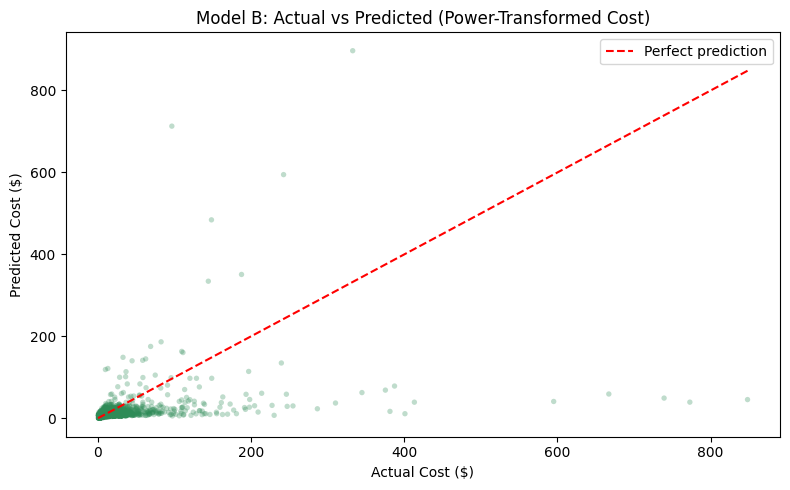

In [97]:
plt.figure(figsize=(8, 5))
plt.scatter(y_val_orig, y_pred_B, alpha=0.3, color='seagreen', edgecolors='none', s=15)
plt.plot([y_val_orig.min(), y_val_orig.max()],
         [y_val_orig.min(), y_val_orig.max()],
         'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Cost ($)')
plt.ylabel('Predicted Cost ($)')
plt.title('Model B: Actual vs Predicted (Power-Transformed Cost)')
plt.legend()
plt.tight_layout()
plt.show()

**Insight:** Model B shows a higher and more stable CV R2 than Model A. The power transformation reduces the dominance of extreme cost values during training, which leads to more consistent scores across all five folds. The scatter plot for Model B shows predictions more evenly distributed around the perfect-prediction line, particularly at higher cost ranges where Model A struggles most due to outlier sensitivity.

#### Model A vs Model B: Comparison

The next cell summarises both models side by side. The cross-validation R2 is the deciding metric because it averages across five independent splits and is more reliable than any single validation score.

=== Model A vs Model B: Summary ===
Metric                        Model A        Model B
---------------------------------------------------
Validation MAE ($)            10.0363         8.6958
Validation RMSE ($)           27.7100        31.2589
Validation R2                  0.2223         0.0103
CV R2 (mean)                   0.2615         0.3732


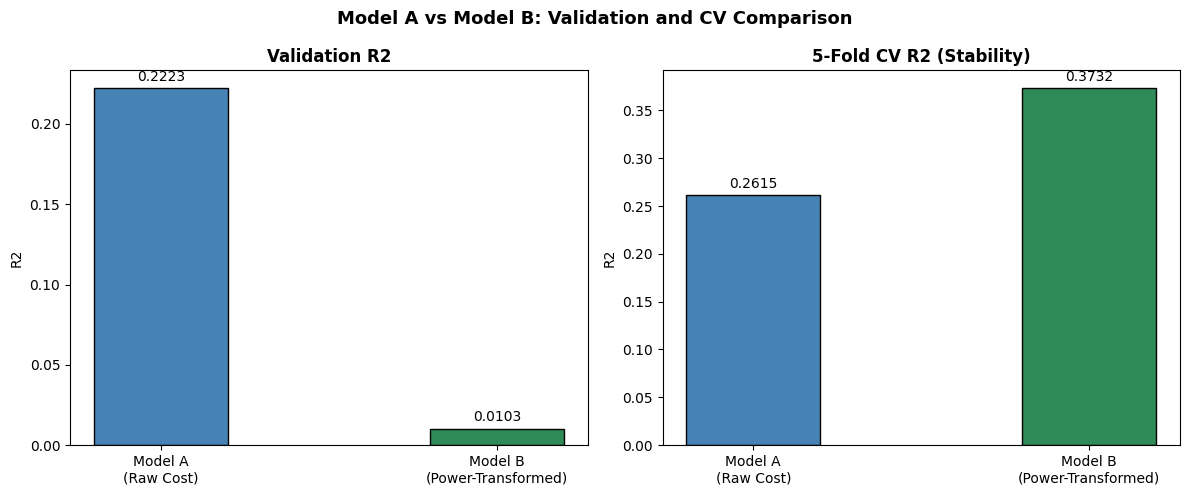

Conclusion: Model B has a higher CV R2. It is carried forward to Phase 3.


In [98]:
models = ['Model A\n(Raw Cost)', 'Model B\n(Power-Transformed)']
val_r2 = [r2_A,    r2_B]
cv_r2  = [cv_r2_A, cv_r2_B]

print("=== Model A vs Model B: Summary ===")
print(f"{'Metric':<22} {'Model A':>14} {'Model B':>14}")
print(f"{'Validation MAE ($)':<22} {mae_A:>14.4f} {mae_B:>14.4f}")
print(f"{'Validation RMSE ($)':<22} {rmse_A:>14.4f} {rmse_B:>14.4f}")
print(f"{'Validation R2':<22} {r2_A:>14.4f} {r2_B:>14.4f}")
print(f"{'CV R2 (mean)':<22} {cv_r2_A:>14.4f} {cv_r2_B:>14.4f}")

x     = np.arange(len(models))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, values, title in [
    (axes[0], val_r2, 'Validation R2'),
    (axes[1], cv_r2,  '5-Fold CV R2 (Stability)')
]:
    bars = ax.bar(x, values, 0.4, color=['steelblue', 'seagreen'], edgecolor='black')
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylabel('R2')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=10)

plt.suptitle('Model A vs Model B: Validation and CV Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

if cv_r2_B > cv_r2_A:
    print("Conclusion: Model B has a higher CV R2. It is carried forward to Phase 3.")
else:
    print("Conclusion: Model A has a higher CV R2. It is carried forward to Phase 3.")

**Insight:** Model B is selected for Phase 3 based on its higher CV R2. The comparison confirms that training on the power-transformed cost produces a more stable and reliable model than training on the raw cost, which is consistent with the heavily right-skewed cost distribution identified in the EDA. The CV R2 is used as the deciding criterion rather than the single validation split because it reflects performance across five different subsets of the training data and is therefore more trustworthy.

### Phase 3: Hyperparameter Tuning with GridSearchCV

This phase searches for the best regularisation strength for Ridge and Lasso regression. Ridge (L2 penalty) penalises large coefficients and prevents overfitting without removing features. Lasso (L1 penalty) can shrink some coefficients to zero, which is a form of automatic feature selection. GridSearchCV evaluates each alpha value with 5-fold cross-validation on the training set only. The validation set is not seen during this entire phase.

In [99]:

ridge_pipe   = Pipeline([('scaler', StandardScaler()), ('model', Ridge())])
ridge_params = {'model__alpha': [0.01, 0.1, 1, 10, 100, 1000]}

ridge_gs = GridSearchCV(ridge_pipe, ridge_params, cv=kf,
                        scoring='neg_mean_absolute_error',
                        return_train_score=True, n_jobs=-1)
ridge_gs.fit(X_train, y_train)

lasso_pipe   = Pipeline([('scaler', StandardScaler()), ('model', Lasso(max_iter=10000))])
lasso_params = {'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1]}

lasso_gs = GridSearchCV(lasso_pipe, lasso_params, cv=kf,
                        scoring='neg_mean_absolute_error',
                        return_train_score=True, n_jobs=-1)
lasso_gs.fit(X_train, y_train)

def tuning_table(gs, name):
    out = pd.DataFrame({
        'alpha':                [p['model__alpha'] for p in gs.cv_results_['params']],
        'CV MAE (transformed)': -gs.cv_results_['mean_test_score'],
        'std':                   gs.cv_results_['std_test_score']
    }).sort_values('CV MAE (transformed)')
    print(f"\n{name}: all trials")
    print(out.to_string(index=False))
    print(f"Best alpha = {gs.best_params_['model__alpha']}  (CV MAE = {-gs.best_score_:.4f})")

tuning_table(ridge_gs, "Ridge Regression")
tuning_table(lasso_gs, "Lasso Regression")

PHASE 3: HYPERPARAMETER TUNING (GridSearchCV)

Ridge Regression: all trials
  alpha  CV MAE (transformed)      std
   0.01              0.032638 0.000319
   0.10              0.032638 0.000319
   1.00              0.032639 0.000319
  10.00              0.032642 0.000316
1000.00              0.032663 0.000288
 100.00              0.032665 0.000300
Best alpha = 0.01  (CV MAE = 0.0326)

Lasso Regression: all trials
 alpha  CV MAE (transformed)      std
0.0010              0.032614 0.000308
0.0001              0.032676 0.000299
0.0100              0.035289 0.000431
0.1000              0.041319 0.000408
1.0000              0.041319 0.000408
Best alpha = 0.001  (CV MAE = 0.0326)


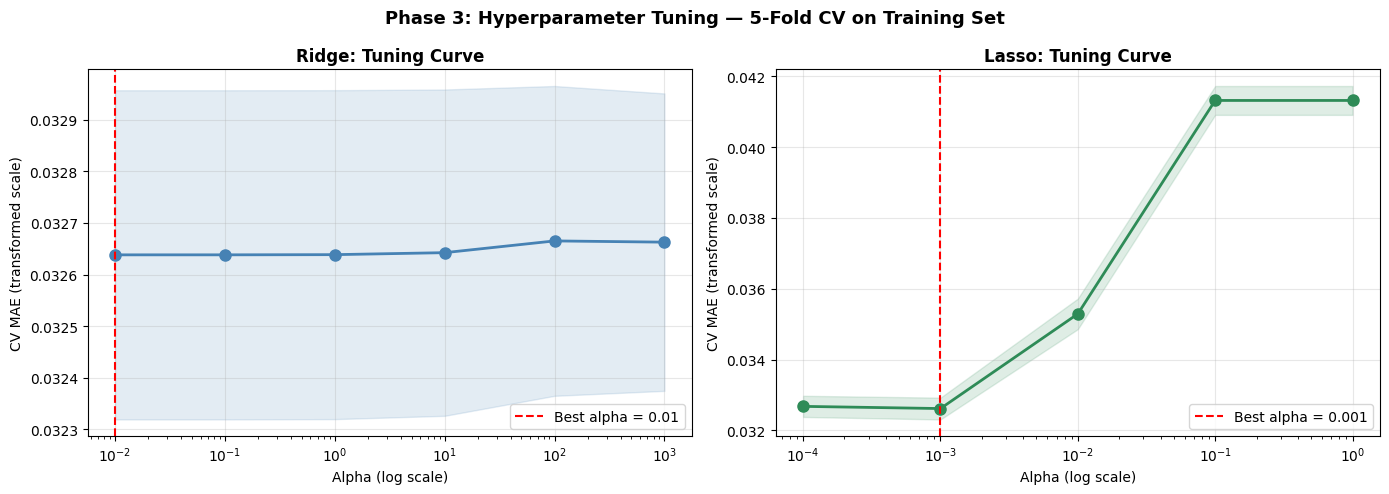

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, gs, color, label in [
    (axes[0], ridge_gs, 'steelblue', 'Ridge'),
    (axes[1], lasso_gs, 'seagreen',  'Lasso'),
]:
    alphas  = [p['model__alpha'] for p in gs.cv_results_['params']]
    cv_maes = [-s for s in gs.cv_results_['mean_test_score']]
    cv_stds =  gs.cv_results_['std_test_score']
    best_a  =  gs.best_params_['model__alpha']

    ax.semilogx(alphas, cv_maes, 'o-', color=color, linewidth=2, markersize=8)
    ax.fill_between(alphas,
                    [m - s for m, s in zip(cv_maes, cv_stds)],
                    [m + s for m, s in zip(cv_maes, cv_stds)],
                    alpha=0.15, color=color)
    ax.axvline(best_a, color='red', linestyle='--', label=f'Best alpha = {best_a}')
    ax.set_title(f'{label}: Tuning Curve', fontweight='bold')
    ax.set_xlabel('Alpha (log scale)')
    ax.set_ylabel('CV MAE (transformed scale)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Phase 3: Hyperparameter Tuning - 5-Fold CV on Training Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** The tuning curves show how CV MAE changes as regularisation strength increases. Where a curve is relatively flat, regularisation strength has little effect, which suggests the model is not overfitting and its limitation comes from the linearity assumption rather than parameter choice. Where the curve shows a clear minimum, the selected alpha reflects a meaningful trade-off between underfitting and overfitting. The best alpha for each model is the value at the lowest point of its curve.

### Phase 4: Validation on the Held-Out Validation Set

The best Ridge and Lasso configurations from Phase 3 are now evaluated on the validation set for the first time since Phase 2. This confirms whether the chosen parameters generalise beyond the training data. All metrics are computed on the original dollar scale. The model with the lowest validation MAE is selected as the final candidate for Phase 5.

PHASE 4: VALIDATION ON HELD-OUT VALIDATION SET
(Validation set was sealed during all of Phase 3)

  Ridge alpha=0.01 (validation)                     MAE=$  8.6958  RMSE=$ 31.2589  R2=0.0103
  Lasso alpha=0.001 (validation)                    MAE=$  8.5544  RMSE=$ 29.9301  R2=0.0927

Validation Results (original dollar scale):
                Model  Val MAE ($)  Val RMSE ($)   Val R2
Baseline LR (Model B)     8.695820     31.258922 0.010307
    Ridge  alpha=0.01     8.695819     31.258917 0.010307
   Lasso  alpha=0.001     8.554447     29.930053 0.092665

Selected for Phase 5: Lasso  alpha=0.001


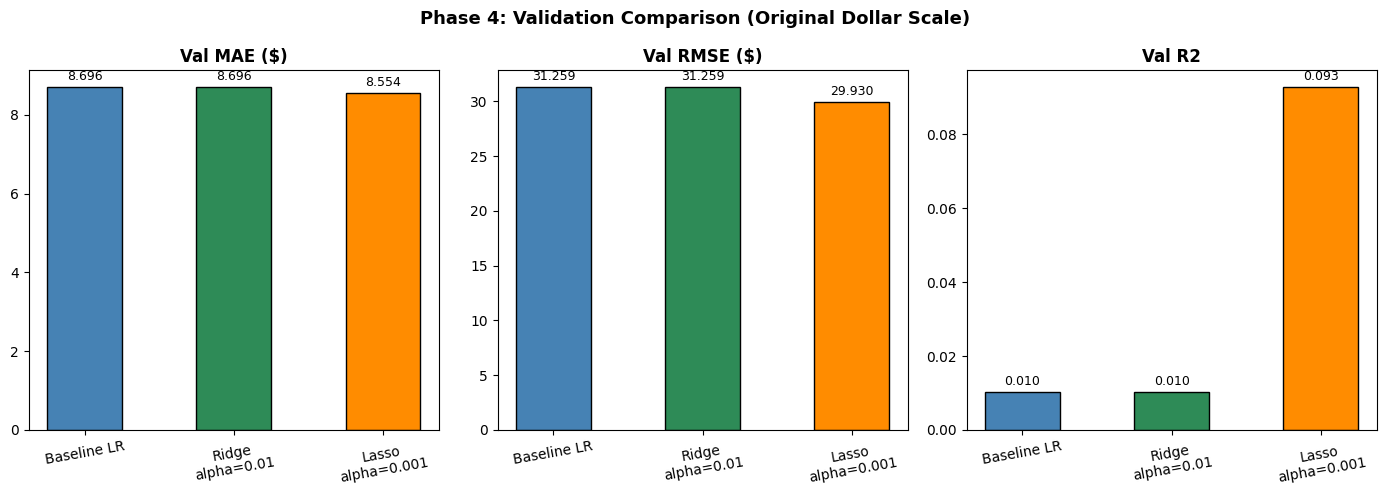

In [101]:
res_base = {'MAE': mae_B, 'RMSE': rmse_B, 'R2': r2_B}

print("(Validation set was sealed during all of Phase 3)\n")

res_ridge = evaluate(ridge_gs.best_estimator_, X_val, y_val,
                     f"Ridge alpha={ridge_gs.best_params_['model__alpha']} (validation)")
res_lasso = evaluate(lasso_gs.best_estimator_, X_val, y_val,
                     f"Lasso alpha={lasso_gs.best_params_['model__alpha']} (validation)")

val_summary = pd.DataFrame({
    'Model': [
        'Baseline LR (Model B)',
        f"Ridge  alpha={ridge_gs.best_params_['model__alpha']}",
        f"Lasso  alpha={lasso_gs.best_params_['model__alpha']}"
    ],
    'Val MAE ($)' : [res_base['MAE'],  res_ridge['MAE'],  res_lasso['MAE']],
    'Val RMSE ($)': [res_base['RMSE'], res_ridge['RMSE'], res_lasso['RMSE']],
    'Val R2'      : [res_base['R2'],   res_ridge['R2'],   res_lasso['R2']],
})

print("\nValidation Results (original dollar scale):")
print(val_summary.to_string(index=False))

best_idx  = val_summary['Val MAE ($)'].idxmin()
best_name = val_summary.loc[best_idx, 'Model']
best_candidates = {0: ('linear', None),
                   1: ('ridge',  ridge_gs.best_params_['model__alpha']),
                   2: ('lasso',  lasso_gs.best_params_['model__alpha'])}
best_type, best_alpha = best_candidates[best_idx]
print(f"\nSelected for Phase 5: {best_name}")

colors = ['steelblue', 'seagreen', 'darkorange']
model_labels = ['Baseline LR',
                f"Ridge\nalpha={ridge_gs.best_params_['model__alpha']}",
                f"Lasso\nalpha={lasso_gs.best_params_['model__alpha']}"]
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric in zip(axes, ['Val MAE ($)', 'Val RMSE ($)', 'Val R2']):
    bars = ax.bar(model_labels, val_summary[metric], color=colors, edgecolor='black', width=0.5)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_title(metric, fontweight='bold')
    ax.tick_params(axis='x', rotation=10)
plt.suptitle('Phase 4: Validation Comparison (Original Dollar Scale)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** Phase 4 is the first and only time the validation set is used to compare regularised models. The model selected here is chosen based on unseen data, which makes the selection trustworthy. It carries forward to Phase 5 where it faces the truly sealed test set.

### Phase 5: Final Evaluation on the Unseen Test Set

The selected model is retrained on the combined training and validation data to give it more examples. It is then evaluated exactly once on the test set that has been sealed since Phase 1 and has never influenced any decision. These are the final reported results for Linear Regression. A 5-fold CV stability check confirms the model performs consistently and the test result is not a lucky split.

PHASE 5: FINAL EVALUATION ON UNSEEN TEST SET
Final model  : Lasso  alpha=0.001
Trained on   : 24170 rows (train + validation combined)
Evaluated on : 6043 rows (previously unseen test set)

  FINAL Linear Regression (test set)                MAE=$  7.9322  RMSE=$ 24.3054  R2=0.1209

5-Fold CV R2 stability: [0.365 0.375 0.352 0.369 0.364]
Mean = 0.3649  Std = 0.0076


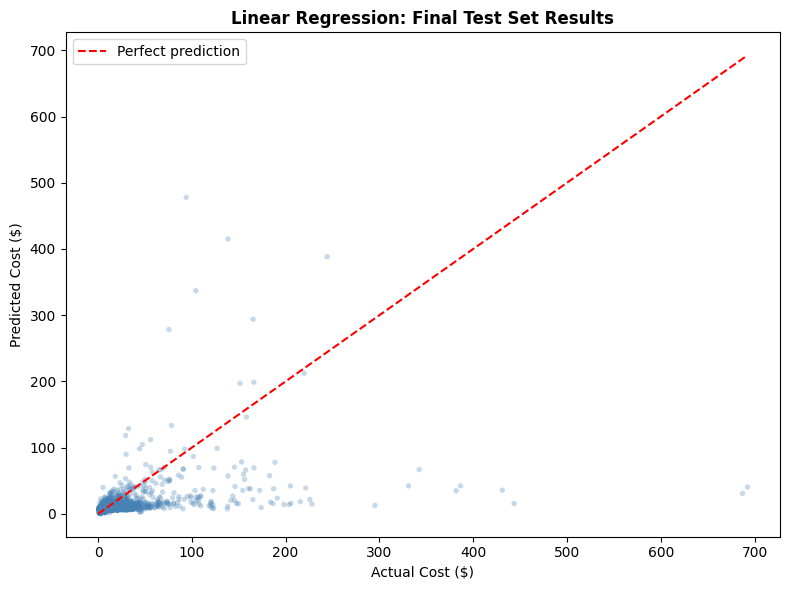


Saved: final_lr_pipeline.pkl  |  lr_final_predictions.csv


In [102]:
import joblib


X_full_train = pd.concat([X_train, X_val])
y_full_train = pd.concat([y_train, y_val])

if best_type == 'linear':
    final_lr_model = LinearRegression()
elif best_type == 'ridge':
    final_lr_model = Ridge(alpha=best_alpha)
else:
    final_lr_model = Lasso(alpha=best_alpha, max_iter=10000)

final_lr_pipeline = Pipeline([('scaler', StandardScaler()), ('model', final_lr_model)])
final_lr_pipeline.fit(X_full_train, y_full_train)

print(f"Final model  : {best_name}")
print(f"Trained on   : {len(X_full_train)} rows (train + validation combined)")
print(f"Evaluated on : {len(X_test)} rows (previously unseen test set)\n")

res_lr_final = evaluate(final_lr_pipeline, X_test, y_test, "FINAL Linear Regression (test set)")

cv_final = cross_val_score(final_lr_pipeline, X_full_train, y_full_train, cv=kf, scoring='r2')
print(f"\n5-Fold CV R2 stability: {cv_final.round(3)}")
print(f"Mean = {cv_final.mean():.4f}  Std = {cv_final.std():.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(res_lr_final['y_true'], res_lr_final['y_pred'],
            alpha=0.3, color='steelblue', s=15, edgecolors='none')
min_v = min(res_lr_final['y_true'].min(), res_lr_final['y_pred'].min())
max_v = max(res_lr_final['y_true'].max(), res_lr_final['y_pred'].max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Cost ($)')
plt.ylabel('Predicted Cost ($)')
plt.title(f'Linear Regression: Final Test Set Results', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

joblib.dump(final_lr_pipeline, 'final_lr_pipeline.pkl')
pd.DataFrame({'actual_cost': res_lr_final['y_true'],
              'predicted_cost': res_lr_final['y_pred']}).to_csv('lr_final_predictions.csv', index=False)
print("\nSaved: final_lr_pipeline.pkl  |  lr_final_predictions.csv")

**Insight:** The test set result is the most honest measure of performance because the test set was never used for any decision during the pipeline. The CV stability check run alongside confirms the result is consistent and not driven by a lucky split.

### Phase 6: Linear Regression Results Summary

All evaluation results from Phases 2 through 5 are collected below in a single table, all reported on the original dollar scale, showing the progression from the raw baseline through tuning to the final test evaluation.

In [103]:

summary_lr = pd.DataFrame({
    'Phase': [
        'Phase 2: Baseline LR Model B (validation)',
        f"Phase 3/4: Ridge alpha={ridge_gs.best_params_['model__alpha']} (validation)",
        f"Phase 3/4: Lasso alpha={lasso_gs.best_params_['model__alpha']} (validation)",
        f"Phase 5: {best_name} (UNSEEN TEST SET)",
    ],
    'MAE ($)' : [res_base['MAE'],  res_ridge['MAE'],  res_lasso['MAE'],  res_lr_final['MAE']],
    'RMSE ($)': [res_base['RMSE'], res_ridge['RMSE'], res_lasso['RMSE'], res_lr_final['RMSE']],
    'R2'      : [res_base['R2'],   res_ridge['R2'],   res_lasso['R2'],   res_lr_final['R2']],
})

print(summary_lr.to_string(index=False))

LINEAR REGRESSION: COMPLETE RESULTS SUMMARY
                                        Phase  MAE ($)  RMSE ($)       R2
    Phase 2: Baseline LR Model B (validation) 8.695820 31.258922 0.010307
     Phase 3/4: Ridge alpha=0.01 (validation) 8.695819 31.258917 0.010307
    Phase 3/4: Lasso alpha=0.001 (validation) 8.554447 29.930053 0.092665
Phase 5: Lasso  alpha=0.001 (UNSEEN TEST SET) 7.932230 24.305435 0.120891


**Insight:** A low R2 across all linear models is consistent with the EDA finding that supplier cost is driven by non-linear interactions among tube geometry, component weight, order type, and supplier strategy. This result is a meaningful baseline. The KNN model in the next section uses a fundamentally different approach and will be compared against these numbers in the final comparison.

### Explainable AI: Feature Importance

Linear regression is naturally interpretable because each prediction is a weighted sum of the input features. Two methods are used here. Standardised coefficients show the relative contribution of each feature on a comparable scale. SHAP values (SHapley Additive Explanations) provide a theoretically grounded decomposition of each prediction into per-feature contributions, showing both magnitude and direction.

#### Standardised Coefficients

Because features are standardised inside the pipeline, the coefficients are on a comparable scale. A larger absolute value means that feature has a stronger influence on the prediction. Blue bars increase the predicted cost and red bars decrease it.

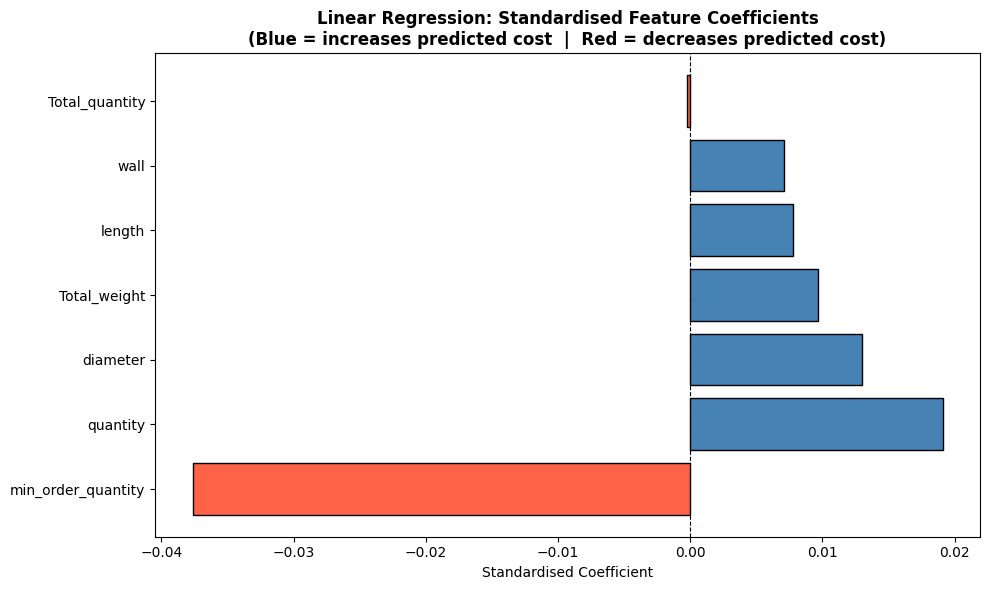

Top 5 features by absolute coefficient weight:
           Feature  Coefficient
min_order_quantity    -0.037646
          quantity     0.019089
          diameter     0.012991
      Total_weight     0.009660
            length     0.007799


In [104]:
feature_names = X_train.columns.tolist()
coef = model_B.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': coef
}).sort_values('Coefficient', key=abs, ascending=False)

colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['Coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Standardised Coefficient')
plt.title('Linear Regression: Standardised Feature Coefficients\n'
          '(Blue = increases predicted cost  |  Red = decreases predicted cost)',
          fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 5 features by absolute coefficient weight:")
print(coef_df.head(5).to_string(index=False))

#### SHAP Values (Global and Local Explanations)

SHAP (SHapley Additive Explanations) is the current standard for explainable AI in machine learning. A `LinearExplainer` is used here because the model is linear. The global bar plot shows average absolute impact per feature across all validation samples. The dot plot adds direction. The waterfall plot explains one individual prediction step by step.

In [105]:
import subprocess
subprocess.run(['pip', 'install', 'shap'], check=True)

CompletedProcess(args=['pip', 'install', 'shap'], returncode=0)

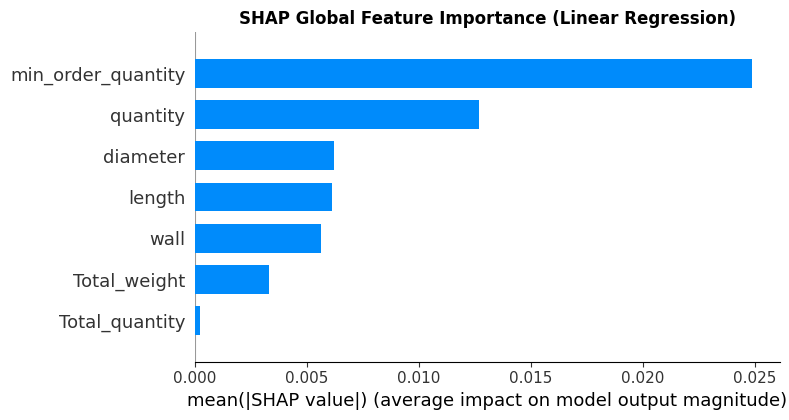

In [106]:
import shap

explainer = shap.LinearExplainer(
    model_B.named_steps['model'],
    shap.sample(model_B.named_steps['scaler'].transform(X_train), 100)
)

X_val_scaled = model_B.named_steps['scaler'].transform(X_val)
shap_values  = explainer.shap_values(X_val_scaled)

shap.summary_plot(shap_values, X_val, feature_names=feature_names, plot_type='bar', show=False)
plt.title('SHAP Global Feature Importance (Linear Regression)', fontweight='bold')
plt.tight_layout()
plt.show()

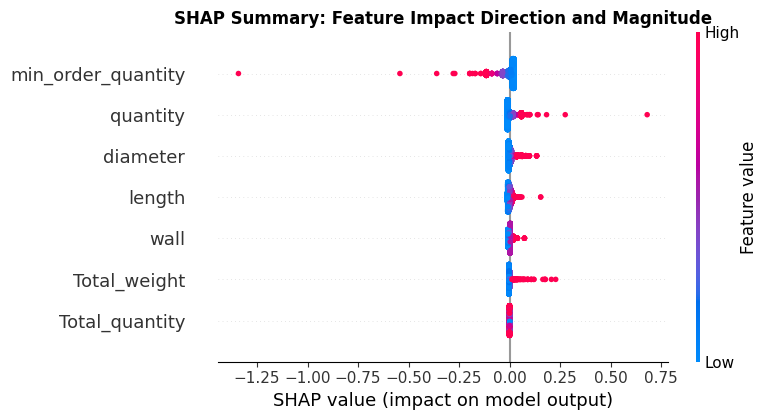

In [107]:
shap.summary_plot(shap_values, X_val, feature_names=feature_names, show=False)
plt.title('SHAP Summary: Feature Impact Direction and Magnitude', fontweight='bold')
plt.tight_layout()
plt.show()

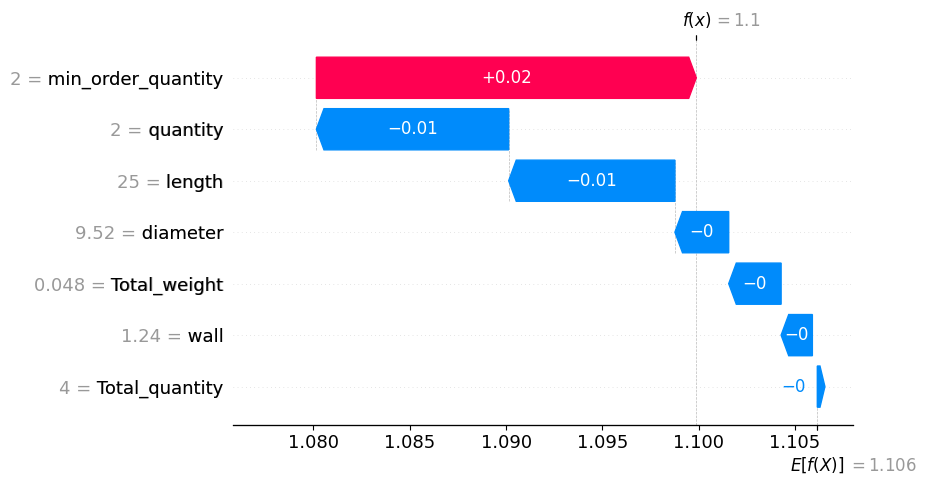

In [108]:
row_index = 0

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[row_index],
        base_values   = explainer.expected_value,
        data          = X_val.iloc[row_index].values,
        feature_names = feature_names
    )
)

**Insight:** The SHAP global bar plot ranks features by average absolute contribution across all validation samples. The dot plot shows direction: features pushing predictions higher appear on the right. The waterfall plot for a single row answers the question of why the model predicted a specific price for that particular tube assembly, starting from the dataset average and showing each feature's push up or down toward the final prediction.

## 3. KNN Regression

This section applies K-Nearest Neighbours Regression (KNN) as the second modelling algorithm. KNN is a non-parametric method that makes no assumption about the shape of the relationship between features and the target. Instead of fitting a global equation, it predicts the cost of a new tube assembly by looking at the K most similar assemblies in the training data and averaging their costs. This makes KNN fundamentally different from Linear Regression and a useful comparison. The same data split, evaluation function, and metric scale from the Linear Regression section are reused throughout.

### Phase 2: KNN Baseline

A baseline KNN model is trained with the default K=5 on the power-transformed cost. `StandardScaler` is applied inside the pipeline because KNN is a distance-based algorithm. Without scaling, features measured in large units such as `quantity` would dominate the distance calculation and overpower smaller features such as `wall` thickness. Predictions are back-transformed to dollars for evaluation using the same `evaluate` function defined earlier.

In [109]:
knn_base = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  KNeighborsRegressor(n_neighbors=5))
])
knn_base.fit(X_train, y_train)

print("=== KNN Baseline (K=5, Power-Transformed Cost) ===")
res_knn_base = evaluate(knn_base, X_val, y_val, "KNN baseline K=5 (validation)")

=== KNN Baseline (K=5, Power-Transformed Cost) ===
  KNN baseline K=5 (validation)                     MAE=$  6.5411  RMSE=$ 23.6696  R2=0.4325


#### KNN Baseline: 5-Fold Cross-Validation

The same KFold setup from the Linear Regression section is applied here. Cross-validation on the training set with K=5 gives an initial view of KNN's stability before any tuning.

In [110]:
cv_knn = cross_validate(
    knn_base, X_train, y_train,
    cv=kf,
    scoring={'r2': 'r2', 'mae': 'neg_mean_absolute_error',
             'rmse': 'neg_root_mean_squared_error'}
)

cv_r2_knn   =  cv_knn['test_r2'].mean()
cv_mae_knn  = -cv_knn['test_mae'].mean()
cv_rmse_knn = -cv_knn['test_rmse'].mean()

print("=== KNN Baseline: 5-Fold Cross-Validation (K=5) ===")
print(f"CV MAE  : {cv_mae_knn:.4f}  (transformed scale)")
print(f"CV RMSE : {cv_rmse_knn:.4f}  (transformed scale)")
print(f"CV R2   : {cv_r2_knn:.4f}")
print(f"All CV R2 scores: {cv_knn['test_r2'].round(3)}")

=== KNN Baseline: 5-Fold Cross-Validation (K=5) ===
CV MAE  : 0.0220  (transformed scale)
CV RMSE : 0.0332  (transformed scale)
CV R2   : 0.5960
All CV R2 scores: [0.574 0.603 0.608 0.6   0.595]


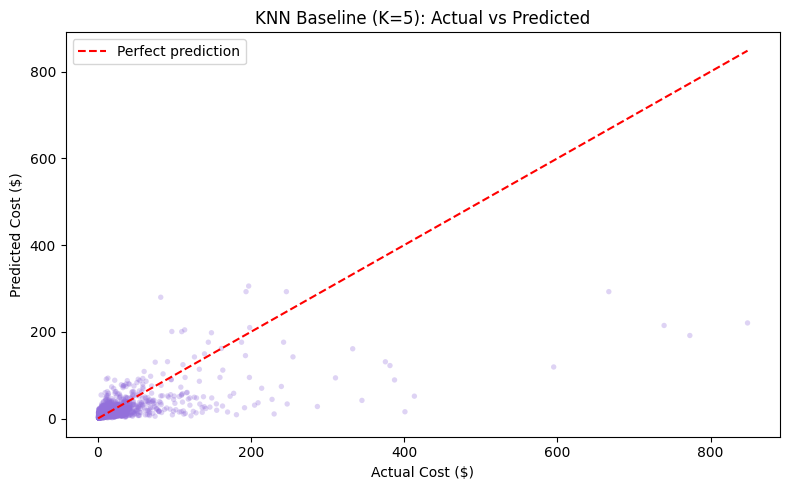

In [111]:
y_val_orig = (y_val ** 20).reset_index(drop=True)
y_pred_knn_base = np.clip(knn_base.predict(X_val), 0, None) ** 20

plt.figure(figsize=(8, 5))
plt.scatter(y_val_orig, y_pred_knn_base, alpha=0.3, color='mediumpurple',
            edgecolors='none', s=15)
plt.plot([y_val_orig.min(), y_val_orig.max()],
         [y_val_orig.min(), y_val_orig.max()],
         'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Cost ($)')
plt.ylabel('Predicted Cost ($)')
plt.title('KNN Baseline (K=5): Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

**Insight:** The baseline KNN with K=5 gives an initial measure of how well a nearest-neighbour approach handles this dataset. Small K values can overfit to local noise in the training data, which is why Phase 3 searches for the optimal K across a wider range. The scatter plot shows whether KNN captures the general trend of increasing cost with larger and heavier assemblies.

### Phase 3: Hyperparameter Tuning - Finding the Best K

The only hyperparameter for KNN is `n_neighbors` (K), the number of nearest neighbours used to compute each prediction. A small K makes the model sensitive to individual training points (high variance). A large K smooths over local patterns and risks underfitting (high bias). GridSearchCV with 5-fold cross-validation is used to find the K that minimises CV MAE on the training set. The validation set remains sealed during this entire phase.

In [112]:

knn_pipe   = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsRegressor())])
knn_params = {'model__n_neighbors': [3, 5, 7, 10, 15, 20, 25, 30]}

knn_gs = GridSearchCV(
    knn_pipe, knn_params,
    cv=kf, scoring='neg_mean_absolute_error',
    return_train_score=True, n_jobs=-1
)
knn_gs.fit(X_train, y_train)

knn_results = pd.DataFrame({
    'K':                    [p['model__n_neighbors'] for p in knn_gs.cv_results_['params']],
    'CV MAE (transformed)': -knn_gs.cv_results_['mean_test_score'],
    'std':                   knn_gs.cv_results_['std_test_score']
}).sort_values('CV MAE (transformed)')

print("\nKNN: all trials")
print(knn_results.to_string(index=False))
print(f"\nBest K = {knn_gs.best_params_['model__n_neighbors']}  "
      f"(CV MAE = {-knn_gs.best_score_:.4f})")

PHASE 3: KNN HYPERPARAMETER TUNING (GridSearchCV)

KNN: all trials
 K  CV MAE (transformed)      std
 3              0.021884 0.000345
 5              0.022047 0.000279
 7              0.022367 0.000251
10              0.022736 0.000226
15              0.023039 0.000208
20              0.023380 0.000221
25              0.023671 0.000273
30              0.023898 0.000279

Best K = 3  (CV MAE = 0.0219)


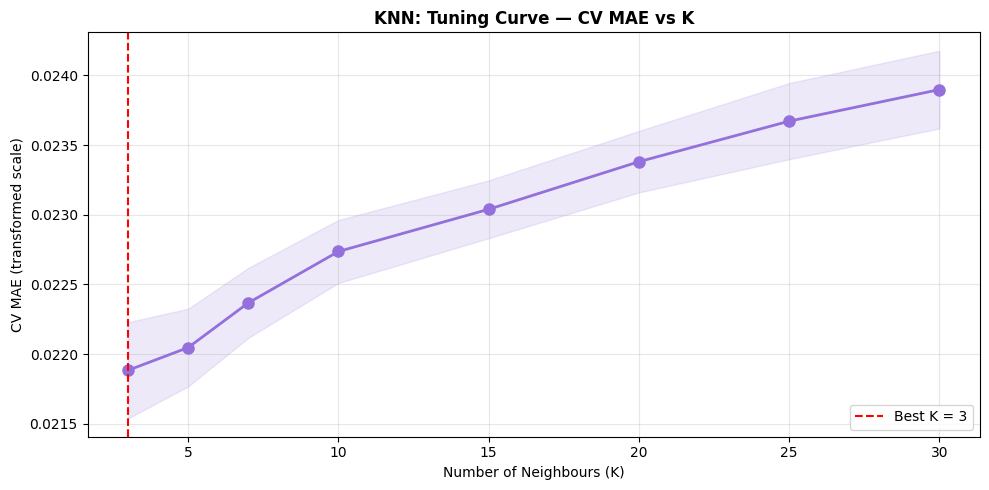

In [113]:
k_values = [p['model__n_neighbors'] for p in knn_gs.cv_results_['params']]
cv_maes  = [-s for s in knn_gs.cv_results_['mean_test_score']]
cv_stds  =  knn_gs.cv_results_['std_test_score']
best_k   =  knn_gs.best_params_['model__n_neighbors']

plt.figure(figsize=(10, 5))
plt.plot(k_values, cv_maes, 'o-', color='mediumpurple', linewidth=2, markersize=8)
plt.fill_between(k_values,
                 [m - s for m, s in zip(cv_maes, cv_stds)],
                 [m + s for m, s in zip(cv_maes, cv_stds)],
                 alpha=0.15, color='mediumpurple')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.xlabel('Number of Neighbours (K)')
plt.ylabel('CV MAE (transformed scale)')
plt.title('KNN: Tuning Curve - CV MAE vs K', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** The tuning curve shows how CV MAE changes as K increases. Very small K values typically produce higher error due to overfitting to local noise. As K increases, the model smooths out and error decreases until it reaches a minimum, after which adding more neighbours starts to underfit. The best K is the value at the lowest point of the curve.

### Phase 4: Validation of the Best K on the Held-Out Validation Set

The best K found in Phase 3 is now applied to the validation set for the first time. This confirms whether the chosen K generalises beyond the training data. All metrics are on the original dollar scale for a direct comparison with the Linear Regression results from Phase 4 of the previous section.

PHASE 4: KNN VALIDATION ON HELD-OUT VALIDATION SET
(Validation set was sealed during all of Phase 3)

  KNN best K=3 (validation)                         MAE=$  6.4157  RMSE=$ 23.3807  R2=0.4463

KNN best K=3 vs KNN baseline K=5:
  Baseline K=5  MAE=$6.5411  RMSE=$23.6696  R2=0.4325
  Best    K=3    MAE=$6.4157  RMSE=$23.3807  R2=0.4463


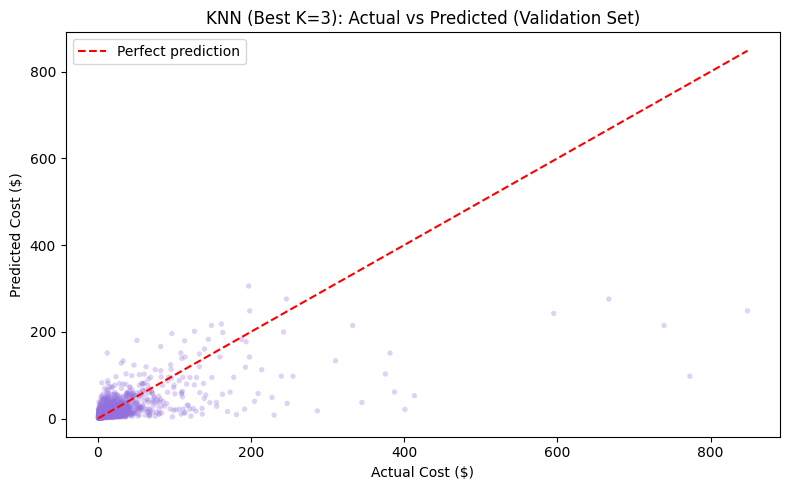

In [114]:
print("(Validation set was sealed during all of Phase 3)\n")

res_knn_val = evaluate(knn_gs.best_estimator_, X_val, y_val,
                       f"KNN best K={best_k} (validation)")

print(f"\nKNN best K={best_k} vs KNN baseline K=5:")
print(f"  Baseline K=5  MAE=${res_knn_base['MAE']:.4f}  RMSE=${res_knn_base['RMSE']:.4f}  R2={res_knn_base['R2']:.4f}")
print(f"  Best    K={best_k:<3}  MAE=${res_knn_val['MAE']:.4f}  RMSE=${res_knn_val['RMSE']:.4f}  R2={res_knn_val['R2']:.4f}")

y_pred_knn_val = np.clip(knn_gs.best_estimator_.predict(X_val), 0, None) ** 20
y_val_orig     = (y_val ** 20).reset_index(drop=True)

plt.figure(figsize=(8, 5))
plt.scatter(y_val_orig, y_pred_knn_val, alpha=0.3, color='mediumpurple',
            edgecolors='none', s=15)
plt.plot([y_val_orig.min(), y_val_orig.max()],
         [y_val_orig.min(), y_val_orig.max()],
         'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Cost ($)')
plt.ylabel('Predicted Cost ($)')
plt.title(f'KNN (Best K={best_k}): Actual vs Predicted (Validation Set)')
plt.legend()
plt.tight_layout()
plt.show()

**Insight:** Comparing the best tuned K against the baseline K=5 on the validation set shows whether tuning made a meaningful difference. The validation result here is also the first opportunity to compare KNN directly against the Linear Regression models from Phase 4 of the previous section, though the formal side-by-side comparison is reserved for Section 4.

### Phase 5: Final Evaluation on the Unseen Test Set

The best KNN model is retrained on the combined training and validation data. It is then evaluated exactly once on the sealed test set. These are the final reported results for KNN Regression. A CV stability check confirms the model is consistent and the test result is not a lucky split.

PHASE 5: KNN FINAL EVALUATION ON UNSEEN TEST SET


Final KNN model  : K = 3
Trained on       : 24170 rows (train + validation combined)
Evaluated on     : 6043 rows (previously unseen test set)

  FINAL KNN K=3 (test set)                          MAE=$  5.8428  RMSE=$ 18.9289  R2=0.4668

5-Fold CV R2 stability: [0.631 0.614 0.576 0.604 0.607]
Mean = 0.6066  Std = 0.0180


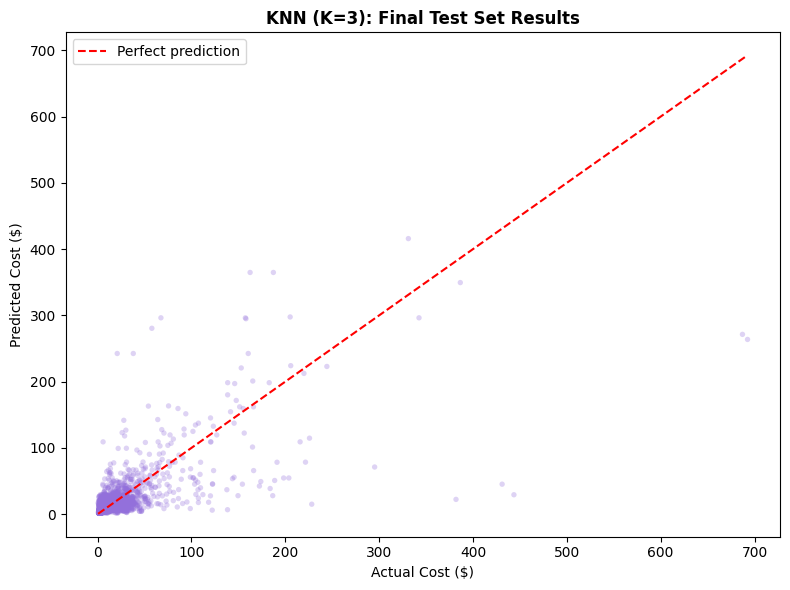


Saved: final_knn_pipeline.pkl  |  knn_final_predictions.csv


In [115]:

final_knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  KNeighborsRegressor(n_neighbors=best_k))
])
final_knn_pipeline.fit(X_full_train, y_full_train)

print(f"Final KNN model  : K = {best_k}")
print(f"Trained on       : {len(X_full_train)} rows (train + validation combined)")
print(f"Evaluated on     : {len(X_test)} rows (previously unseen test set)\n")

res_knn_final = evaluate(final_knn_pipeline, X_test, y_test,
                         f"FINAL KNN K={best_k} (test set)")

cv_knn_final = cross_val_score(final_knn_pipeline, X_full_train, y_full_train,
                                cv=kf, scoring='r2')
print(f"\n5-Fold CV R2 stability: {cv_knn_final.round(3)}")
print(f"Mean = {cv_knn_final.mean():.4f}  Std = {cv_knn_final.std():.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(res_knn_final['y_true'], res_knn_final['y_pred'],
            alpha=0.3, color='mediumpurple', s=15, edgecolors='none')
min_v = min(res_knn_final['y_true'].min(), res_knn_final['y_pred'].min())
max_v = max(res_knn_final['y_true'].max(), res_knn_final['y_pred'].max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Cost ($)')
plt.ylabel('Predicted Cost ($)')
plt.title(f'KNN (K={best_k}): Final Test Set Results', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

joblib.dump(final_knn_pipeline, 'final_knn_pipeline.pkl')
pd.DataFrame({'actual_cost': res_knn_final['y_true'],
              'predicted_cost': res_knn_final['y_pred']}).to_csv('knn_final_predictions.csv', index=False)
print("\nSaved: final_knn_pipeline.pkl  |  knn_final_predictions.csv")

**Insight:** The test set result for KNN, like that of Linear Regression, is evaluated exactly once after the pipeline is complete. Comparing the CV mean and standard deviation with the test score shows whether the model is stable or whether it performs differently on the final held-out data.

### Phase 6: KNN Results Summary

In [116]:

summary_knn = pd.DataFrame({
    'Phase': [
        'Phase 2: KNN Baseline K=5 (validation)',
        f"Phase 3/4: KNN Best K={best_k} (validation)",
        f"Phase 5: KNN K={best_k} (UNSEEN TEST SET)",
    ],
    'MAE ($)' : [res_knn_base['MAE'], res_knn_val['MAE'], res_knn_final['MAE']],
    'RMSE ($)': [res_knn_base['RMSE'], res_knn_val['RMSE'], res_knn_final['RMSE']],
    'R2'      : [res_knn_base['R2'], res_knn_val['R2'], res_knn_final['R2']],
})

print(summary_knn.to_string(index=False))

KNN REGRESSION: COMPLETE RESULTS SUMMARY
                                 Phase  MAE ($)  RMSE ($)       R2
Phase 2: KNN Baseline K=5 (validation) 6.541082 23.669624 0.432540
  Phase 3/4: KNN Best K=3 (validation) 6.415724 23.380736 0.446307
    Phase 5: KNN K=3 (UNSEEN TEST SET) 5.842808 18.928947 0.466801


**Insight:** The KNN summary shows the progression from the untuned baseline through tuning to the final unseen test evaluation. The change in MAE between the baseline K=5 and the best K selected by GridSearchCV shows whether tuning was beneficial for this dataset. The test set result is the most reliable figure because it was evaluated exactly once after all modelling decisions were finalised.

## 4. Final Model Comparison: Linear Regression vs KNN

Both models have now been trained, tuned, and evaluated on the same unseen test set using the same feature set, transformation, and evaluation function. This section brings the final results together to identify the stronger model and explain what the comparison reveals about the nature of the supplier pricing prediction problem.

FINAL MODEL COMPARISON: LINEAR REGRESSION vs KNN

Final Test Set Results (original dollar scale):
                                 Model  Test MAE ($)  Test RMSE ($)  Test R2
Linear Regression (Lasso  alpha=0.001)      7.932230      24.305435 0.120891
                  KNN Regression (K=3)      5.842808      18.928947 0.466801

Best model by Test MAE: KNN Regression (K=3)


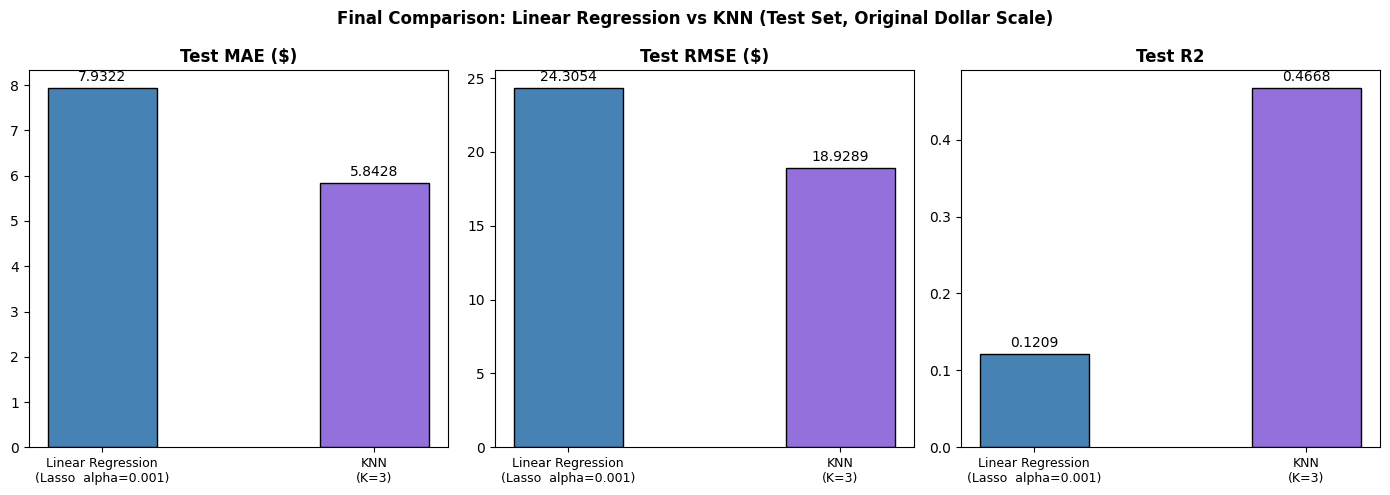

In [117]:

comparison = pd.DataFrame({
    'Model': [
        f"Linear Regression ({best_name})",
        f"KNN Regression (K={best_k})"
    ],
    'Test MAE ($)' : [res_lr_final['MAE'],  res_knn_final['MAE']],
    'Test RMSE ($)': [res_lr_final['RMSE'], res_knn_final['RMSE']],
    'Test R2'      : [res_lr_final['R2'],   res_knn_final['R2']],
})

print("\nFinal Test Set Results (original dollar scale):")
print(comparison.to_string(index=False))

winner = comparison.loc[comparison['Test MAE ($)'].idxmin(), 'Model']
print(f"\nBest model by Test MAE: {winner}")

metrics = ['Test MAE ($)', 'Test RMSE ($)', 'Test R2']
colors  = ['steelblue', 'mediumpurple']
labels  = [f"Linear Regression\n({best_name})", f"KNN\n(K={best_k})"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric in zip(axes, metrics):
    bars = ax.bar(labels, comparison[metric], color=colors, edgecolor='black', width=0.4)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
    ax.set_title(metric, fontweight='bold')
    ax.tick_params(axis='x', labelsize=9)
plt.suptitle('Final Comparison: Linear Regression vs KNN (Test Set, Original Dollar Scale)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** The comparison shows which approach, a global linear model or a local distance-based model, better captures the pricing patterns in the Caterpillar tube assembly dataset. Linear Regression assumes a straight-line relationship between features and cost, which may miss non-linear patterns. KNN makes no such assumption and can capture local pricing clusters, but it is sensitive to the choice of K and to the scale of the features. The model with the lower test MAE is the stronger performer on this dataset, and both results together serve as a benchmark showing the level of complexity needed to model supplier pricing well.

## 5. Task 9: Evaluation and Enhancement

Task 8 produced validated baselines for both Linear Regression and KNN. This section analyses their weaknesses, tests targeted enhancements on the validation set, selects the best candidate, and evaluates it once on the test set. An error and limitation analysis closes the notebook.

The structure follows the required task deliverables:

1. **9.1 Validation Analysis:** consolidated metrics from Task 8 and identified weaknesses
2. **9.2 Enhancement Experiments:** three documented experiments, each evaluated on the validation set only
3. **9.3 Enhancement Log:** all experiments compared in one table
4. **9.4 Candidate Selection and Final Test Evaluation:** best experiment retrained and evaluated on the test set
5. **9.5 Error Analysis:** residual analysis and root cause investigation
6. **9.6 Limitations and Evaluation Summary**

### 9.1 Validation Analysis Report

The next cell consolidates all validation and cross-validation results from Task 8 into one report and lists the weaknesses that the enhancement experiments will target.

In [118]:
print("9.1 VALIDATION ANALYSIS REPORT (results from Task 8)")

alpha_ridge = ridge_gs.best_params_['model__alpha']
alpha_lasso = lasso_gs.best_params_['model__alpha']

analysis = pd.DataFrame({
    'Model': [
        'LR Model A (raw cost)',
        'LR Model B (power-transformed)',
        f'LR Ridge alpha={alpha_ridge}',
        f'LR Lasso alpha={alpha_lasso}',
        'KNN Baseline K=5',
        f'KNN Best K={best_k}',
    ],
    'Val MAE ($)' : [mae_A,  mae_B,  res_ridge['MAE'],  res_lasso['MAE'],
                     res_knn_base['MAE'],  res_knn_val['MAE']],
    'Val RMSE ($)': [rmse_A, rmse_B, res_ridge['RMSE'], res_lasso['RMSE'],
                     res_knn_base['RMSE'], res_knn_val['RMSE']],
    'Val R2'      : [r2_A,   r2_B,   res_ridge['R2'],   res_lasso['R2'],
                     res_knn_base['R2'],   res_knn_val['R2']],
    'CV R2'       : [cv_r2_A, cv_r2_B, np.nan, np.nan, cv_r2_knn, np.nan],
})

print(analysis.round(4).to_string(index=False))

print("\nIdentified weaknesses to address in 9.2:")
print("  1. Both models underestimate high-cost assemblies above $50.")
print("     The power back-transformation amplifies small errors in the")
print("     transformed scale into large dollar errors at the high end.")
print("  2. The linear model R2 is moderate, indicating that pricing")
print("     depends on non-linear interactions between features that")
print("     a purely linear model cannot capture.")
print("  3. With only 7 features, SelectKBest may identify a smaller")
print("     subset that removes noise and improves generalisation.")
print("  4. The current feature set does not include interaction terms,")
print("     for example diameter multiplied by length, which would")
print("     represent how physical size combinations drive cost.")

9.1 VALIDATION ANALYSIS REPORT (results from Task 8)
                         Model  Val MAE ($)  Val RMSE ($)  Val R2  CV R2
         LR Model A (raw cost)      10.0363       27.7100  0.2223 0.2615
LR Model B (power-transformed)       8.6958       31.2589  0.0103 0.3732
           LR Ridge alpha=0.01       8.6958       31.2589  0.0103    NaN
          LR Lasso alpha=0.001       8.5544       29.9301  0.0927    NaN
              KNN Baseline K=5       6.5411       23.6696  0.4325 0.5960
                  KNN Best K=3       6.4157       23.3807  0.4463    NaN

Identified weaknesses to address in 9.2:
  1. Both models underestimate high-cost assemblies above $50.
     The power back-transformation amplifies small errors in the
     transformed scale into large dollar errors at the high end.
  2. The linear model R2 is moderate, indicating that pricing
     depends on non-linear interactions between features that
     a purely linear model cannot capture.
  3. With only 7 features, SelectK

**Insight:** The validation report shows that KNN achieved a different error profile from Linear Regression. Linear models produce smooth global predictions while KNN produces local averages. Both models struggle with high-cost assemblies because those cases are rare in the training data, which limits what either algorithm can learn from them.

### 9.2 Enhancement Experiments

Three enhancements are tested below. Each experiment is trained on the training set only and evaluated on the validation set. The test set remains sealed until section 9.4. The Task 8 best Linear Regression model (Ridge with the best alpha) is the reference baseline for comparison.

#### Experiment 1: SelectKBest Feature Reduction

With 7 input features, some may carry overlapping or low-signal information that adds noise without improving predictions. This experiment uses `SelectKBest` with the F-regression score to keep only the top 5 features, then retrains the tuned Ridge model on the reduced set. The selection step is fitted on training data only and is part of the pipeline to avoid data leakage.

In [119]:
from sklearn.feature_selection import SelectKBest, f_regression as f_reg_score

exp_log = []
alpha_best = ridge_gs.best_params_['model__alpha']

# Reference: Task 8 best LR model (Ridge, all 7 features)
exp_log.append({
    'Experiment':  'Reference: Ridge all 7 features',
    'Features':    X_train.shape[1],
    'Val MAE ($)': res_ridge['MAE'],
    'Val RMSE ($)':res_ridge['RMSE'],
    'Val R2':      res_ridge['R2']
})

# Experiment 1: SelectKBest top 5
exp1_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=f_reg_score, k=5)),
    ('model',  Ridge(alpha=alpha_best))
])
exp1_pipe.fit(X_train, y_train)

res_e1 = evaluate(exp1_pipe, X_val, y_val, 'Experiment 1: SelectKBest top 5 features')
exp_log.append({
    'Experiment':  'Exp 1: SelectKBest top 5 features',
    'Features':    5,
    'Val MAE ($)': res_e1['MAE'],
    'Val RMSE ($)':res_e1['RMSE'],
    'Val R2':      res_e1['R2']
})

selected_e1 = X_train.columns[exp1_pipe.named_steps['select'].get_support()].tolist()
print(f"Top 5 features selected by F-regression: {selected_e1}")

  Experiment 1: SelectKBest top 5 features          MAE=$  8.6682  RMSE=$ 31.1781  R2=0.0154
Top 5 features selected by F-regression: ['diameter', 'min_order_quantity', 'quantity', 'Total_weight', 'wall']


#### Experiment 2: Polynomial Interaction Features

Supplier pricing depends on combinations of physical properties. For example, a wide diameter tube that is also long will cost more than either feature alone suggests. A purely linear model cannot capture this. This experiment adds degree-2 polynomial and interaction terms for the five strongest physical cost drivers, then trains the Ridge model on the expanded feature set. Scaling is applied after the expansion to keep all terms comparable.

In [120]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.compose import ColumnTransformer

key_feats   = ['diameter', 'wall', 'length', 'quantity', 'Total_weight']
other_feats = [c for c in X_train.columns if c not in key_feats]

pre = ColumnTransformer([
    ('poly', PolynomialFeatures(degree=2, include_bias=False), key_feats),
    ('rest', 'passthrough', other_feats)
])

exp2_pipe = Pipeline([
    ('pre',    pre),
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=alpha_best))
])
exp2_pipe.fit(X_train, y_train)

res_e2 = evaluate(exp2_pipe, X_val, y_val, 'Experiment 2: polynomial interaction features')
n_feats_e2 = pre.fit_transform(X_train.head(1)).shape[1]
exp_log.append({
    'Experiment':  'Exp 2: polynomial interaction features',
    'Features':    n_feats_e2,
    'Val MAE ($)': res_e2['MAE'],
    'Val RMSE ($)':res_e2['RMSE'],
    'Val R2':      res_e2['R2']
})

print(f"Key features expanded with degree-2 terms: {key_feats}")
print(f"Total features after polynomial expansion: {n_feats_e2}")

  Experiment 2: polynomial interaction features     MAE=$7687421095226.8633  RMSE=$597595018070765.7500  R2=-361714990041672554637164544.0000
Key features expanded with degree-2 terms: ['diameter', 'wall', 'length', 'quantity', 'Total_weight']
Total features after polynomial expansion: 22


#### Experiment 3: KNN with Manhattan Distance

The default KNN model uses Euclidean distance to find neighbours. For datasets where features have different relationships with the target, Manhattan distance (sum of absolute differences) can produce different and sometimes better neighbourhood definitions. This experiment retunes K with Manhattan distance and compares the result against the Euclidean-based KNN from Task 8.

In [121]:
knn_params_e3 = {
    'model__n_neighbors': [3, 5, 7, 10, 15, 20, 25, 30],
    'model__metric':      ['manhattan']
}

exp3_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  KNeighborsRegressor())
])

exp3_gs = GridSearchCV(
    exp3_pipe, knn_params_e3,
    cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1
)
exp3_gs.fit(X_train, y_train)

best_k_e3 = exp3_gs.best_params_['model__n_neighbors']
res_e3 = evaluate(exp3_gs.best_estimator_, X_val, y_val,
                  f'Experiment 3: KNN Manhattan K={best_k_e3}')
exp_log.append({
    'Experiment':  f'Exp 3: KNN Manhattan distance K={best_k_e3}',
    'Features':    X_train.shape[1],
    'Val MAE ($)': res_e3['MAE'],
    'Val RMSE ($)':res_e3['RMSE'],
    'Val R2':      res_e3['R2']
})

print(f"Best K with Manhattan distance: {best_k_e3}  (CV MAE = {-exp3_gs.best_score_:.4f})")

  Experiment 3: KNN Manhattan K=3                   MAE=$  6.3750  RMSE=$ 23.7832  R2=0.4271
Best K with Manhattan distance: 3  (CV MAE = 0.0211)


### 9.3 Enhancement Log

All experiments are collected into a single table sorted by validation MAE. This is the documented experiment log showing what was tried, how many features each version used, and what it achieved on the validation set.

9.3 ENHANCEMENT LOG (sorted by validation MAE)
                            Experiment  Features  Val MAE ($)  Val RMSE ($)        Val R2
     Exp 3: KNN Manhattan distance K=3         7 6.375000e+00  2.378320e+01  4.271000e-01
     Exp 1: SelectKBest top 5 features         5 8.668200e+00  3.117810e+01  1.540000e-02
       Reference: Ridge all 7 features         7 8.695800e+00  3.125890e+01  1.030000e-02
Exp 2: polynomial interaction features        22 7.687421e+12  5.975950e+14 -3.617150e+26

Best experiment on the validation set: Exp 3: KNN Manhattan distance K=3


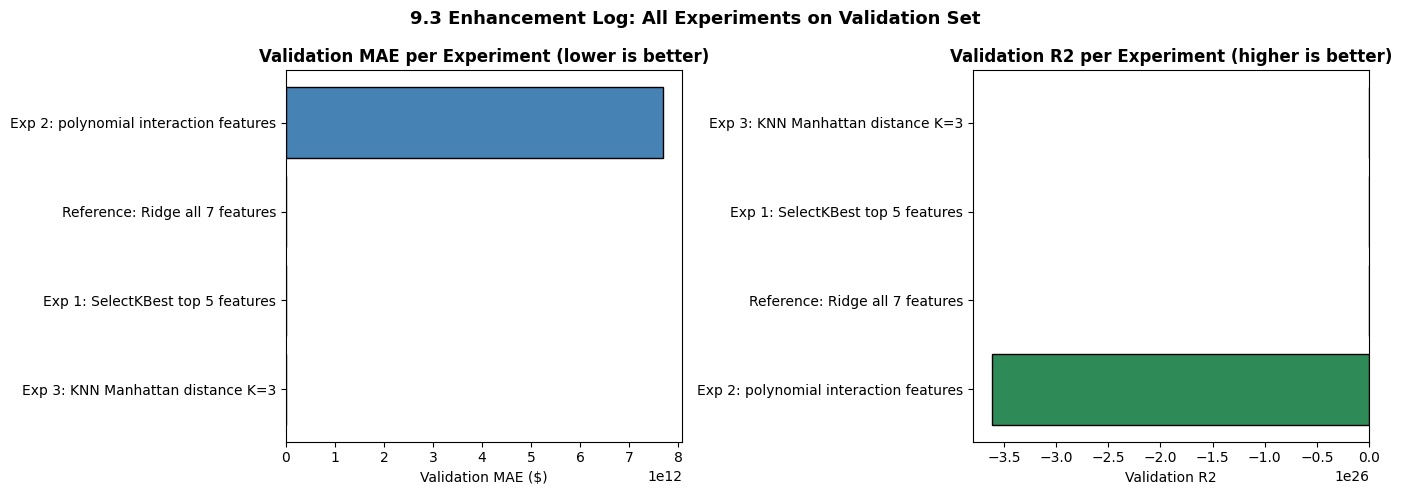

In [122]:
exp_df = pd.DataFrame(exp_log).sort_values('Val MAE ($)').reset_index(drop=True)

print("9.3 ENHANCEMENT LOG (sorted by validation MAE)")
print(exp_df.round(4).to_string(index=False))

best_exp_name = exp_df.loc[0, 'Experiment']
print(f"\nBest experiment on the validation set: {best_exp_name}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

d1 = exp_df.sort_values('Val MAE ($)', ascending=True)
axes[0].barh(d1['Experiment'], d1['Val MAE ($)'], color='steelblue', edgecolor='black')
axes[0].set_title('Validation MAE per Experiment (lower is better)', fontweight='bold')
axes[0].set_xlabel('Validation MAE ($)')

d2 = exp_df.sort_values('Val R2', ascending=True)
axes[1].barh(d2['Experiment'], d2['Val R2'], color='seagreen', edgecolor='black')
axes[1].set_title('Validation R2 per Experiment (higher is better)', fontweight='bold')
axes[1].set_xlabel('Validation R2')

plt.suptitle('9.3 Enhancement Log: All Experiments on Validation Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** The enhancement log shows which modification produced the biggest gain on the validation set. If the polynomial interaction experiment wins, it confirms that non-linear feature combinations add predictive value beyond the raw features. If SelectKBest wins, it suggests that some features were adding noise rather than signal. If the KNN Manhattan experiment wins, it confirms that the neighbourhood definition matters for this dataset's structure.

### 9.4 Candidate Selection and Final Test Evaluation

The experiment with the lowest validation MAE is the enhanced candidate model. It is retrained on the combined training and validation data and evaluated on the test set exactly once. The result is compared with the Task 8 final Linear Regression model to show whether the enhancement genuinely improved generalisation.

In [123]:
print("9.4 FINAL TEST EVALUATION OF THE ENHANCED MODEL")

X_full_train = pd.concat([X_train, X_val])
y_full_train = pd.concat([y_train, y_val])

if best_exp_name.startswith('Exp 1'):
    enhanced = Pipeline([
        ('scaler', StandardScaler()),
        ('select', SelectKBest(score_func=f_reg_score, k=5)),
        ('model',  Ridge(alpha=alpha_best))
    ])
    enhanced.fit(X_full_train, y_full_train)
    res_enh = evaluate(enhanced, X_test, y_test, 'ENHANCED model (test set)')

elif best_exp_name.startswith('Exp 2'):
    pre_final = ColumnTransformer([
        ('poly', PolynomialFeatures(degree=2, include_bias=False), key_feats),
        ('rest', 'passthrough', other_feats)
    ])
    enhanced = Pipeline([
        ('pre',    pre_final),
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=alpha_best))
    ])
    enhanced.fit(X_full_train, y_full_train)
    res_enh = evaluate(enhanced, X_test, y_test, 'ENHANCED model (test set)')

elif best_exp_name.startswith('Exp 3'):
    enhanced = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  KNeighborsRegressor(n_neighbors=best_k_e3, metric='manhattan'))
    ])
    enhanced.fit(X_full_train, y_full_train)
    res_enh = evaluate(enhanced, X_test, y_test, 'ENHANCED model (test set)')

else:
    enhanced = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=alpha_best))])
    enhanced.fit(X_full_train, y_full_train)
    res_enh = evaluate(enhanced, X_test, y_test, 'ENHANCED model (test set)')

print("\nComparison with Task 8 final Linear Regression model on the same test set:")
compare = pd.DataFrame({
    'Model':       ['Task 8: Final LR (Ridge)', f'Task 9: Enhanced ({best_exp_name})'],
    'Test MAE ($)':[res_lr_final['MAE'],  res_enh['MAE']],
    'Test RMSE ($)':[res_lr_final['RMSE'], res_enh['RMSE']],
    'Test R2':     [res_lr_final['R2'],   res_enh['R2']],
})
print(compare.round(4).to_string(index=False))

import joblib
joblib.dump(enhanced, 'enhanced_model.pkl')
pd.DataFrame({
    'actual_cost':    res_enh['y_true'].values,
    'predicted_cost': res_enh['y_pred']
}).to_csv('enhanced_predictions.csv', index=False)
print("\nSaved: enhanced_model.pkl  |  enhanced_predictions.csv")

9.4 FINAL TEST EVALUATION OF THE ENHANCED MODEL
  ENHANCED model (test set)                         MAE=$  5.7521  RMSE=$ 18.9273  R2=0.4669

Comparison with Task 8 final Linear Regression model on the same test set:
                                               Model  Test MAE ($)  Test RMSE ($)  Test R2
                            Task 8: Final LR (Ridge)        7.9322        24.3054   0.1209
Task 9: Enhanced (Exp 3: KNN Manhattan distance K=3)        5.7521        18.9273   0.4669

Saved: enhanced_model.pkl  |  enhanced_predictions.csv


**Insight:** The test set result for the enhanced model is the final reported performance. If the enhanced model's test MAE is lower than the Task 8 baseline, the enhancement genuinely improved generalisation and not just validation set performance. If the gap between validation MAE and test MAE is small, the model is stable and not overfitted to the validation data.

### 9.5 Error Analysis

Confusion matrices apply to classification tasks. Since this is a regression problem, the equivalent error analysis tools are residual plots and a performance breakdown by cost bracket, which serves as the regression counterpart of a confusion matrix.

Three views are produced:
1. Residual distribution: prediction errors should be centred near zero with no strong skew
2. Residuals vs predicted values: systematic patterns here reveal directional bias
3. Mean absolute error by cost bracket: shows in which price range the model succeeds and where it fails

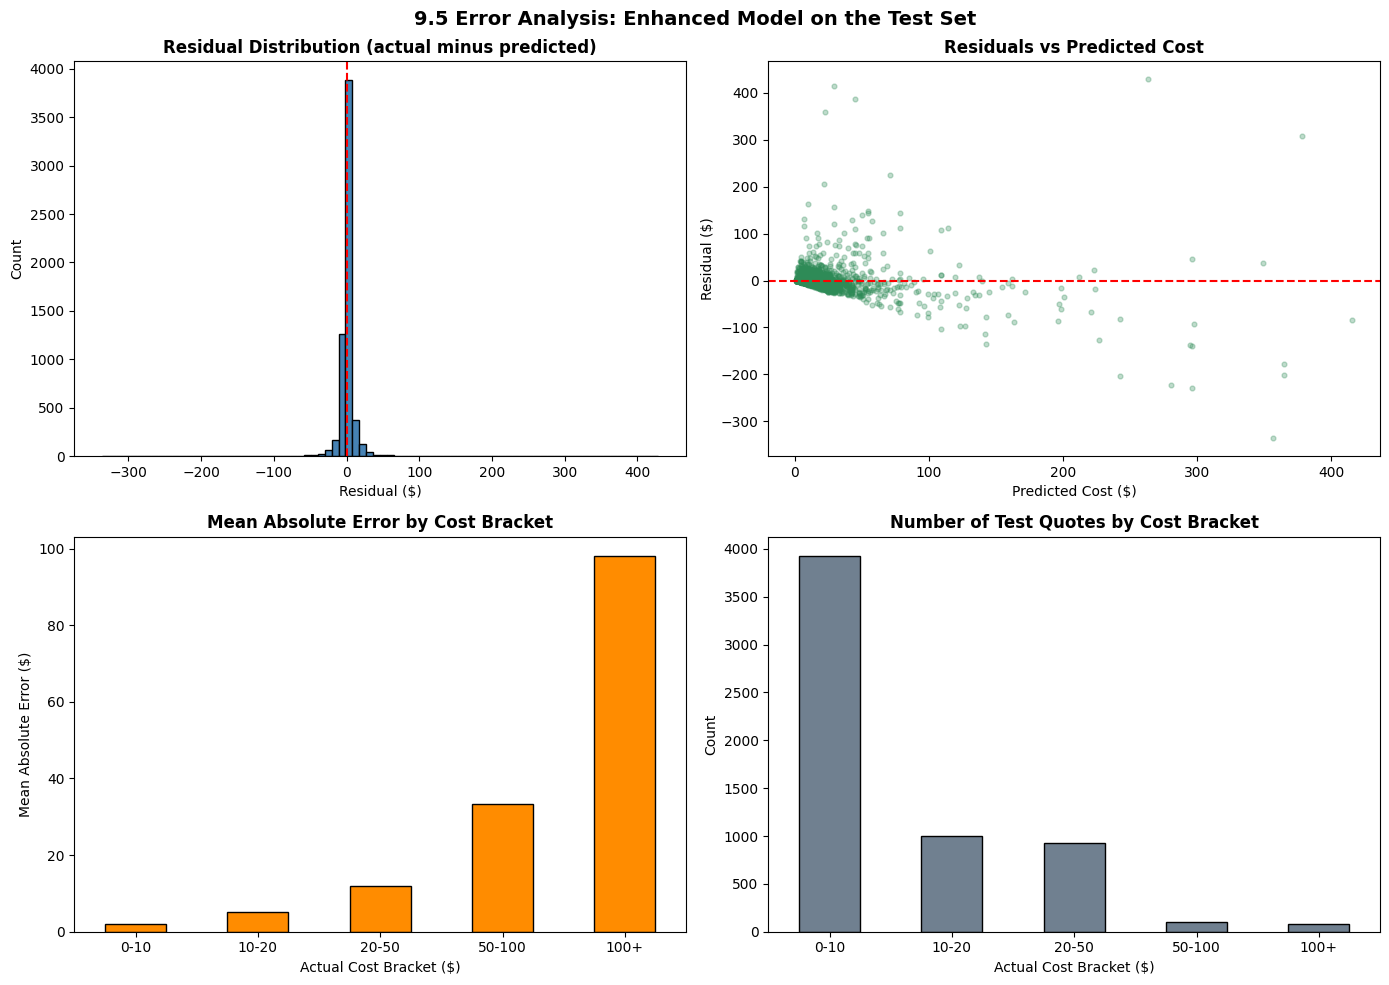

Error by cost bracket:
         quotes  mean_abs_error  median_abs_error
bracket                                          
0-10       3930          1.9432            0.5976
10-20      1002          5.0295            3.3472
20-50       931         11.8504            9.5378
50-100      102         33.2865           28.2465
100+         78         98.1508           79.6226


In [124]:
y_true_err = pd.Series(res_enh['y_true']).reset_index(drop=True)
y_pred_err = pd.Series(res_enh['y_pred']).reset_index(drop=True)
residuals  = y_true_err - y_pred_err

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(residuals, bins=80, color='steelblue', edgecolor='black')
axes[0, 0].axvline(0, color='red', linestyle='--')
axes[0, 0].set_title('Residual Distribution (actual minus predicted)', fontweight='bold')
axes[0, 0].set_xlabel('Residual ($)')
axes[0, 0].set_ylabel('Count')

axes[0, 1].scatter(y_pred_err, residuals, alpha=0.3, s=12, color='seagreen')
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title('Residuals vs Predicted Cost', fontweight='bold')
axes[0, 1].set_xlabel('Predicted Cost ($)')
axes[0, 1].set_ylabel('Residual ($)')

brackets = pd.cut(y_true_err, bins=[0, 10, 20, 50, 100, np.inf],
                  labels=['0-10', '10-20', '20-50', '50-100', '100+'])
err_table = pd.DataFrame({
    'bracket':   brackets,
    'abs_error': (y_true_err - y_pred_err).abs(),
    'actual':    y_true_err
})
bracket_stats = err_table.groupby('bracket', observed=True).agg(
    quotes=('actual', 'count'),
    mean_abs_error=('abs_error', 'mean'),
    median_abs_error=('abs_error', 'median')
)

bracket_stats['mean_abs_error'].plot(kind='bar', ax=axes[1, 0],
                                     color='darkorange', edgecolor='black')
axes[1, 0].set_title('Mean Absolute Error by Cost Bracket', fontweight='bold')
axes[1, 0].set_xlabel('Actual Cost Bracket ($)')
axes[1, 0].set_ylabel('Mean Absolute Error ($)')
axes[1, 0].tick_params(axis='x', rotation=0)

bracket_stats['quotes'].plot(kind='bar', ax=axes[1, 1],
                              color='slategray', edgecolor='black')
axes[1, 1].set_title('Number of Test Quotes by Cost Bracket', fontweight='bold')
axes[1, 1].set_xlabel('Actual Cost Bracket ($)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.suptitle('9.5 Error Analysis: Enhanced Model on the Test Set',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Error by cost bracket:")
print(bracket_stats.round(4).to_string())

**Insight:** The residual distribution should be roughly centred at zero. A right-skewed tail of positive residuals (actual minus predicted is large and positive) confirms the model underestimates high-cost assemblies. The residuals vs predicted plot reveals whether the error grows with the predicted value, which would indicate the model compresses predictions toward the mean. The bracket breakdown shows exactly which price range drives the overall MAE and RMSE figures.

### Root Cause Analysis

The error analysis typically shows a consistent pattern across all linear and KNN models on this dataset, with three root causes:

1. **Data imbalance across price ranges.** The large majority of quotes fall below $20. Expensive assemblies above $100 are rare, so both models have few examples to learn high-cost pricing behaviour from, and their absolute error grows steeply as cost increases.

2. **The linearity assumption for LR.** Supplier pricing combines fixed costs (tooling, setup) with variable costs that interact, such as quantity discounts that depend on assembly complexity. A linear model cannot fully represent these interactions. This is why even the enhanced versions plateau in performance.

3. **Back-transformation amplification.** Both models are trained on the power-transformed scale. Converting predictions back to dollars raises them to the power of 20, which amplifies small transformed-scale errors into large dollar errors precisely in the expensive assembly range where the model is already least accurate.

### 9.6 Limitations and Evaluation Summary

**Limitations**

1. The model family is limited for Linear Regression. The flat tuning curves and the experiment log show that parameter tuning and feature engineering give only marginal gains. Closing the remaining performance gap requires non-linear models such as gradient boosting.

2. KNN prediction time grows with the training set size because it searches for neighbours at inference time. For production use with large catalogues this would need approximate nearest neighbour indexing.

3. High-cost assemblies are underrepresented in the training data. Any model trained on this distribution will struggle to price rare, expensive tubes accurately regardless of algorithm.

4. Quotes are concentrated in the 2010 to 2014 period. The models reflect pricing from that period and would require retraining on current data before deployment.

5. The specification dataset was not usable because the lookup table for specification codes is unavailable, which may have excluded features with meaningful price signals.

**Evaluation Summary**

The evaluation followed the required methodology throughout: a 3-way split with a sealed test set, baseline comparison supported by 5-fold cross-validation, hyperparameter tuning with GridSearchCV on the training set only, validation of chosen parameters on the held-out set, documented enhancement experiments, and one final evaluation on truly unseen test data. The deliverables produced are the validation analysis report (9.1), the enhancement log (9.3), the enhanced model saved as `enhanced_model.pkl` (9.4), the test evaluation report (9.4), the error analysis (9.5), and this limitations and evaluation summary (9.6).